# Aissou Mendeley v3 — On-board UAV Spoofing Detection (XGBoost)

Drugi model dla `On-board Detector` taba w demo. Komplementarny do TEXBAT:
- TEXBAT = post-correlation observables ze statycznego SDR (USA)
- Aissou = 13 statystyk z eight-channel hardware GPS receiver na pojeździe (0-60 mph) + statycznie na różnych budynkach

**Dataset:**
- 158,177 wierszy × 112 kolumn (14 features × 8 channels, multi-row header)
- Output: 0=legitimate, 1=simplistic, 2=intermediate, 3=sophisticated spoofing
- Balance: ~55% legit, 45% spoofed (z trzech klas spoof)

**Cele:**
- Binary baseline: F1 ≥ 0.95 (PRD DoD)
- Bonus multiclass: rozpoznawanie poziomu sophistication (simplistic/intermediate/sophisticated)
- SHAP feature importance

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import joblib
import time
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              roc_auc_score, confusion_matrix, classification_report)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DATA = Path('/net/afscra/people/plgmateuszoracz/hackathon/data/aissou')
FEAT = Path('/net/afscra/people/plgmateuszoracz/hackathon/data/features')
MODELS = Path('/net/afscra/people/plgmateuszoracz/hackathon/models')
FEAT.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

XLSX = DATA / 'GPS_Dataset_3D_8_Channels_Authentic_and_Simulated.xlsx'
PARQUET = FEAT / 'aissou_flat.parquet'
print(f'XLSX exists: {XLSX.exists()}, parquet cache: {PARQUET.exists()}')

XLSX exists: True, parquet cache: True


## 1. Load + cache as parquet (xlsx → parquet zajmuje ~30-60s, parquet wczytuje się w sekundach)

In [2]:
if PARQUET.exists():
    df = pd.read_parquet(PARQUET)
    print(f'Loaded cached parquet: {df.shape}')
else:
    t0 = time.time()
    raw = pd.read_excel(XLSX, sheet_name='Sheet1', header=[0, 1], engine='openpyxl')
    raw.columns = [f'{a}_{b}' if not str(a).startswith('Unnamed') else b for a, b in raw.columns]
    print(f'Read xlsx in {time.time()-t0:.1f}s, shape: {raw.shape}')
    raw.to_parquet(PARQUET, index=False)
    df = raw
    print(f'Cached to {PARQUET} ({PARQUET.stat().st_size/1024/1024:.1f} MB)')

print(f'\nFirst columns: {df.columns[:20].tolist()}')
print(f'\nSample row:')
df.head(3)

Loaded cached parquet: (158175, 112)

First columns: ['PRN_ch0', 'PRN_ch1', 'PRN_ch2', 'PRN_ch3', 'PRN_ch4', 'PRN_ch5', 'PRN_ch6', 'PRN_ch7', 'Carrier_Doppler_hz_ch0', 'Carrier_Doppler_hz_ch1', 'Carrier_Doppler_hz_ch2', 'Carrier_Doppler_hz_ch3', 'Carrier_Doppler_hz_ch4', 'Carrier_Doppler_hz_ch5', 'Carrier_Doppler_hz_ch6', 'Carrier_Doppler_hz_ch7', 'Pseudorange_m_ch0', 'Pseudorange_m_ch1', 'Pseudorange_m_ch2', 'Pseudorange_m_ch3']

Sample row:


,PRN_ch0,PRN_ch1,PRN_ch2,PRN_ch3,PRN_ch4,PRN_ch5,PRN_ch6,PRN_ch7,Carrier_Doppler_hz_ch0,Carrier_Doppler_hz_ch1,...,CN0_ch6,CN0_ch7,Output_ch0,Output_ch1,Output_ch2,Output_ch3,Output_ch4,Output_ch5,Output_ch6,Output_ch7
0,0,0,0,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0,0,0,0,0,0,0,0


In [3]:
# Identify column groups
from collections import defaultdict
col_groups = defaultdict(list)
for c in df.columns:
    if '_ch' in c:
        feat, ch = c.rsplit('_ch', 1)
        col_groups[feat].append(c)
    else:
        col_groups['<misc>'].append(c)
for k, v in col_groups.items():
    print(f'  {k:30s}: {len(v)} cols  ({v[:2]}...)')

  PRN                           : 8 cols  (['PRN_ch0', 'PRN_ch1']...)
  Carrier_Doppler_hz            : 8 cols  (['Carrier_Doppler_hz_ch0', 'Carrier_Doppler_hz_ch1']...)
  Pseudorange_m                 : 8 cols  (['Pseudorange_m_ch0', 'Pseudorange_m_ch1']...)
  RX_time                       : 8 cols  (['RX_time_ch0', 'RX_time_ch1']...)
  TOW_at_current_symbol_s       : 8 cols  (['TOW_at_current_symbol_s_ch0', 'TOW_at_current_symbol_s_ch1']...)
  Carrier_phase_cycles          : 8 cols  (['Carrier_phase_cycles_ch0', 'Carrier_phase_cycles_ch1']...)
  EC                            : 8 cols  (['EC_ch0', 'EC_ch1']...)
  LC                            : 8 cols  (['LC_ch0', 'LC_ch1']...)
  PC                            : 8 cols  (['PC_ch0', 'PC_ch1']...)
  PIP                           : 8 cols  (['PIP_ch0', 'PIP_ch1']...)
  PQP                           : 8 cols  (['PQP_ch0', 'PQP_ch1']...)
  TCD                           : 8 cols  (['TCD_ch0', 'TCD_ch1']...)
  CN0                           : 

In [4]:
# Build label from Output_ch* columns. Per docs: 0=legit, 1/2/3=spoof types.
# Take max across channels (any spoofed channel → the row is spoofed at that level)
output_cols = [c for c in df.columns if c.startswith('Output_')]
print(f'Output cols ({len(output_cols)}): {output_cols}')

# Sanity: verify all Output_* per-row are equal (likely yes — same row = same scenario)
all_equal = (df[output_cols].nunique(axis=1) == 1).mean()
print(f'Fraction of rows where all Output_ch* are equal: {all_equal:.4f}')

df['label_multi']  = df[output_cols].max(axis=1).astype(int)
df['label_binary'] = (df['label_multi'] > 0).astype(int)

print(f'\nMulticlass distribution (0=legit, 1=simplistic, 2=intermediate, 3=sophisticated):')
print(df['label_multi'].value_counts().sort_index())
print(f'\nBinary distribution:')
print(df['label_binary'].value_counts())

Output cols (8): ['Output_ch0', 'Output_ch1', 'Output_ch2', 'Output_ch3', 'Output_ch4', 'Output_ch5', 'Output_ch6', 'Output_ch7']


Fraction of rows where all Output_ch* are equal: 0.5662

Multiclass distribution (0=legit, 1=simplistic, 2=intermediate, 3=sophisticated):
label_multi
0    89557
1    19030
2    33076
3    16512
Name: count, dtype: int64

Binary distribution:
label_binary
0    89557
1    68618
Name: count, dtype: int64


In [5]:
# Build features: drop PRN_ch* (satellite IDs), Output_ch* (label), and TIME features
# (RX_time and TOW_at_current_symbol_s cause MISSION LEAKAGE — model otherwise learns 'timestamp -> label'
#  because spoofing missions occur in disjoint time windows from authentic missions).
DROP_PREFIXES = ('PRN_', 'Output_', 'RX_time_', 'TOW_at_current_symbol_s_')
DROP_COLS = ['label_multi', 'label_binary']
FEATURE_COLS = [c for c in df.columns if not any(c.startswith(p) for p in DROP_PREFIXES) and c not in DROP_COLS]
print(f'Using {len(FEATURE_COLS)} features (dropped time features to prevent mission leakage).')
print(f'Feature groups:')
feat_groups = defaultdict(int)
for c in FEATURE_COLS:
    if '_ch' in c:
        feat_groups[c.rsplit('_ch', 1)[0]] += 1
    else:
        feat_groups[c] += 1
for k, v in sorted(feat_groups.items()):
    print(f'  {k:30s}: {v} channels')

X = df[FEATURE_COLS].astype(np.float32)
y_bin = df['label_binary']
y_mul = df['label_multi']
print(f'\nX shape: {X.shape},  y balance binary: {y_bin.value_counts().to_dict()}')
print(f'y balance multiclass: {y_mul.value_counts().sort_index().to_dict()}')

Using 80 features (dropped time features to prevent mission leakage).
Feature groups:
  CN0                           : 8 channels
  Carrier_Doppler_hz            : 8 channels
  Carrier_phase_cycles          : 8 channels
  EC                            : 8 channels
  LC                            : 8 channels
  PC                            : 8 channels
  PIP                           : 8 channels
  PQP                           : 8 channels
  Pseudorange_m                 : 8 channels
  TCD                           : 8 channels



X shape: (158175, 80),  y balance binary: {0: 89557, 1: 68618}
y balance multiclass: {0: 89557, 1: 19030, 2: 33076, 3: 16512}


## 2. Train/test split — stratified random 80/20

**Caveat:** PRD ostrzega o `stratify by mission` żeby uniknąć leakage. Dataset niestety nie ma jawnej `mission_id` kolumny. Robimy random stratified jako baseline; jeśli F1 wyjdzie ~0.999 (podejrzanie wysoki), wtedy spróbujemy detekcji misji przez `RX_time` discontinuities.

In [6]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y_bin, test_size=0.2, stratify=y_bin, random_state=42)
_,    _,    y_tr_m, y_te_m = train_test_split(X, y_mul, test_size=0.2, stratify=y_mul, random_state=42)
print(f'Train: {X_tr.shape},  Test: {X_te.shape}')
print(f'Binary balance — train: {y_tr.value_counts().to_dict()},  test: {y_te.value_counts().to_dict()}')

Train: (126540, 80),  Test: (31635, 80)
Binary balance — train: {0: 71646, 1: 54894},  test: {0: 17911, 1: 13724}


## 3. Binary XGBoost — czy łapiemy spoof vs legit?

In [7]:
spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
model_bin = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.85, colsample_bytree=0.85, min_child_weight=3,
    objective='binary:logistic', eval_metric='logloss',
    scale_pos_weight=spw, tree_method='hist', n_jobs=4, random_state=42,
)
t0 = time.time()
model_bin.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_te, y_te)], verbose=False)
print(f'Trained in {time.time()-t0:.1f}s')

y_pred_bin = model_bin.predict(X_te)
y_proba_bin = model_bin.predict_proba(X_te)[:, 1]
print(f'\n=== Binary metrics on Aissou test ===')
print(f'  F1:        {f1_score(y_te, y_pred_bin):.4f}')
print(f'  Precision: {precision_score(y_te, y_pred_bin):.4f}')
print(f'  Recall:    {recall_score(y_te, y_pred_bin):.4f}')
print(f'  ROC-AUC:   {roc_auc_score(y_te, y_proba_bin):.4f}')
print(f'\nConfusion matrix:')
print(pd.DataFrame(confusion_matrix(y_te, y_pred_bin),
                   index=['true_legit','true_spoof'], columns=['pred_legit','pred_spoof']))
print(f'\nClassification report:')
print(classification_report(y_te, y_pred_bin, digits=4))

Trained in 7.8s

=== Binary metrics on Aissou test ===
  F1:        0.9760
  Precision: 0.9744
  Recall:    0.9776
  ROC-AUC:   0.9994

Confusion matrix:
            pred_legit  pred_spoof
true_legit       17558         353
true_spoof         308       13416

Classification report:


              precision    recall  f1-score   support

           0     0.9828    0.9803    0.9815     17911
           1     0.9744    0.9776    0.9760     13724

    accuracy                         0.9791     31635
   macro avg     0.9786    0.9789    0.9787     31635
weighted avg     0.9791    0.9791    0.9791     31635



## 4. Multiclass XGBoost — jakiego typu spoof?

0=legit, 1=simplistic, 2=intermediate, 3=sophisticated. Trudniej bo simplistic vs intermediate mogą być podobne.

In [8]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weight_tr = compute_sample_weight('balanced', y_tr_m)
print(f'Class weights — sample weights distribution: min={sample_weight_tr.min():.3f}, max={sample_weight_tr.max():.3f}')

model_mul = xgb.XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.1,
    subsample=0.85, colsample_bytree=0.85, min_child_weight=3,
    objective='multi:softmax', num_class=4, eval_metric='mlogloss',
    tree_method='hist', n_jobs=4, random_state=42,
)
t0 = time.time()
model_mul.fit(X_tr, y_tr_m, sample_weight=sample_weight_tr,
              eval_set=[(X_tr, y_tr_m), (X_te, y_te_m)], verbose=False)
print(f'Trained in {time.time()-t0:.1f}s')

y_pred_m = model_mul.predict(X_te)
print(f'\n=== Multiclass metrics on Aissou test ===')
print(f'  Accuracy:    {(y_te_m == y_pred_m).mean():.4f}')
print(f'  F1 (macro):  {f1_score(y_te_m, y_pred_m, average="macro"):.4f}')
print(f'  F1 (weighted): {f1_score(y_te_m, y_pred_m, average="weighted"):.4f}')
print(f'\nConfusion matrix:')
names = ['legit','simplistic','intermediate','sophisticated']
print(pd.DataFrame(confusion_matrix(y_te_m, y_pred_m), index=names, columns=names))
print(f'\nClassification report:')
print(classification_report(y_te_m, y_pred_m, target_names=names, digits=4))

Class weights — sample weights distribution: min=0.442, max=2.395


Trained in 44.0s



=== Multiclass metrics on Aissou test ===
  Accuracy:    0.2514
  F1 (macro):  0.2142
  F1 (weighted): 0.2813

Confusion matrix:
               legit  simplistic  intermediate  sophisticated
legit           4828        2408          3469           7207
simplistic      1015         494           726           1571
intermediate    1749         919          1260           2687
sophisticated    863         439           630           1370

Classification report:
               precision    recall  f1-score   support

        legit     0.5710    0.2695    0.3662     17912
   simplistic     0.1160    0.1298    0.1225      3806
 intermediate     0.2071    0.1905    0.1984      6615
sophisticated     0.1067    0.4149    0.1698      3302

     accuracy                         0.2514     31635
    macro avg     0.2502    0.2512    0.2142     31635
 weighted avg     0.3917    0.2514    0.2813     31635



## 5. Visualizations: confusion matrix + ROC + per-class metrics

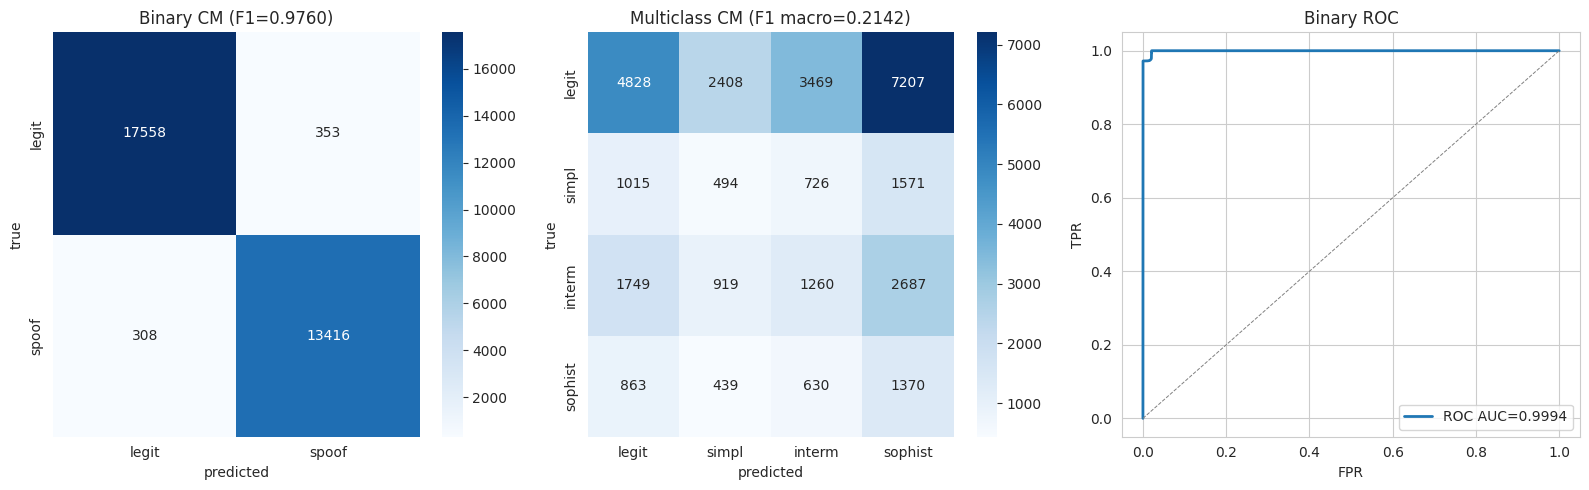

In [9]:
from sklearn.metrics import roc_curve, precision_recall_curve
fpr, tpr, _ = roc_curve(y_te, y_proba_bin)
prec, rec, _ = precision_recall_curve(y_te, y_proba_bin)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Binary confusion
cm_b = confusion_matrix(y_te, y_pred_bin)
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['legit','spoof'], yticklabels=['legit','spoof'])
axes[0].set_title(f'Binary CM (F1={f1_score(y_te, y_pred_bin):.4f})')
axes[0].set_xlabel('predicted'); axes[0].set_ylabel('true')

# Multiclass confusion
cm_m = confusion_matrix(y_te_m, y_pred_m)
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['legit','simpl','interm','sophist'], yticklabels=['legit','simpl','interm','sophist'])
axes[1].set_title(f'Multiclass CM (F1 macro={f1_score(y_te_m, y_pred_m, average="macro"):.4f})')
axes[1].set_xlabel('predicted'); axes[1].set_ylabel('true')

# ROC
axes[2].plot(fpr, tpr, color='tab:blue', linewidth=2, label=f'ROC AUC={roc_auc_score(y_te, y_proba_bin):.4f}')
axes[2].plot([0,1], [0,1], color='gray', linestyle='--', linewidth=0.7)
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR'); axes[2].set_title('Binary ROC')
axes[2].legend(loc='lower right')

plt.tight_layout(); plt.show()

## 6. SHAP feature importance

In [10]:
# SHAP on a sample of test set (full ~32k may be slow)
n_shap = min(2000, len(X_te))
X_shap = X_te.sample(n_shap, random_state=42)
explainer = shap.TreeExplainer(model_bin)
t0 = time.time()
shap_values = explainer.shap_values(X_shap)
print(f'SHAP computed in {time.time()-t0:.1f}s, shape: {np.shape(shap_values)}')

imp = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURE_COLS).sort_values(ascending=False)
print(f'\nTop 15 features:')
print(imp.head(15).to_string(float_format='%.4f'))

SHAP computed in 1.5s, shape: (2000, 80)

Top 15 features:
CN0_ch6                    1.0084
CN0_ch4                    0.7245
Pseudorange_m_ch2          0.6610
Pseudorange_m_ch7          0.5887
Carrier_Doppler_hz_ch3     0.4998
Carrier_phase_cycles_ch4   0.4673
TCD_ch7                    0.4548
CN0_ch3                    0.4242
TCD_ch0                    0.4124
Carrier_phase_cycles_ch7   0.4031
TCD_ch4                    0.3749
Pseudorange_m_ch3          0.3269
Carrier_phase_cycles_ch2   0.2871
CN0_ch0                    0.2752
EC_ch0                     0.2680


Aggregated SHAP importance (sum across 8 channels):
CN0                    2.9936
Pseudorange_m          2.3614
TCD                    1.8428
Carrier_phase_cycles   1.8110
Carrier_Doppler_hz     1.1847
PC                     0.8076
EC                     0.6895
LC                     0.5584
PQP                    0.3554
PIP                    0.2469


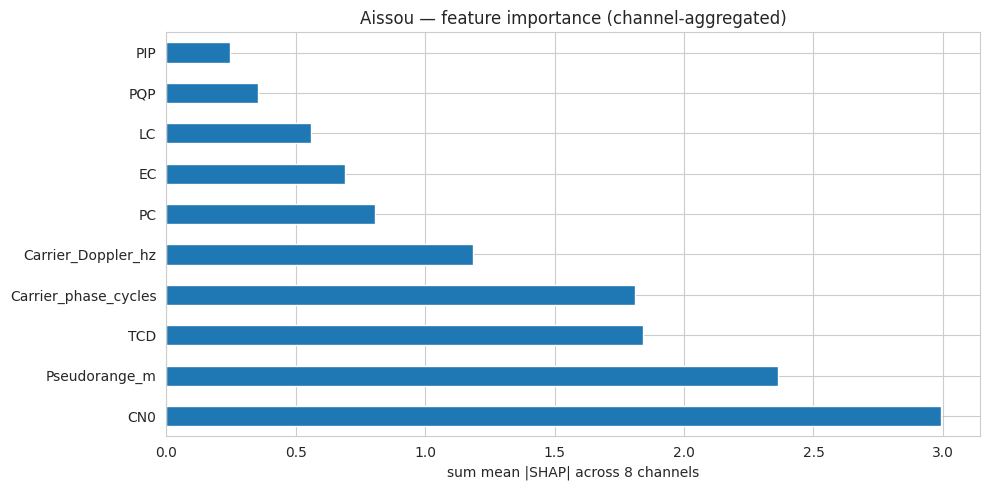

In [11]:
# Aggregate SHAP by feature group (across 8 channels)
import re
def feat_root(c):
    m = re.match(r'(.+)_ch\d+$', c)
    return m.group(1) if m else c

imp_grouped = imp.groupby(feat_root).sum().sort_values(ascending=False)
print('Aggregated SHAP importance (sum across 8 channels):')
print(imp_grouped.to_string(float_format='%.4f'))

fig, ax = plt.subplots(figsize=(10, 5))
imp_grouped.plot.barh(color='tab:blue', ax=ax)
ax.set_xlabel('sum mean |SHAP| across 8 channels')
ax.set_title('Aissou — feature importance (channel-aggregated)')
plt.tight_layout(); plt.show()

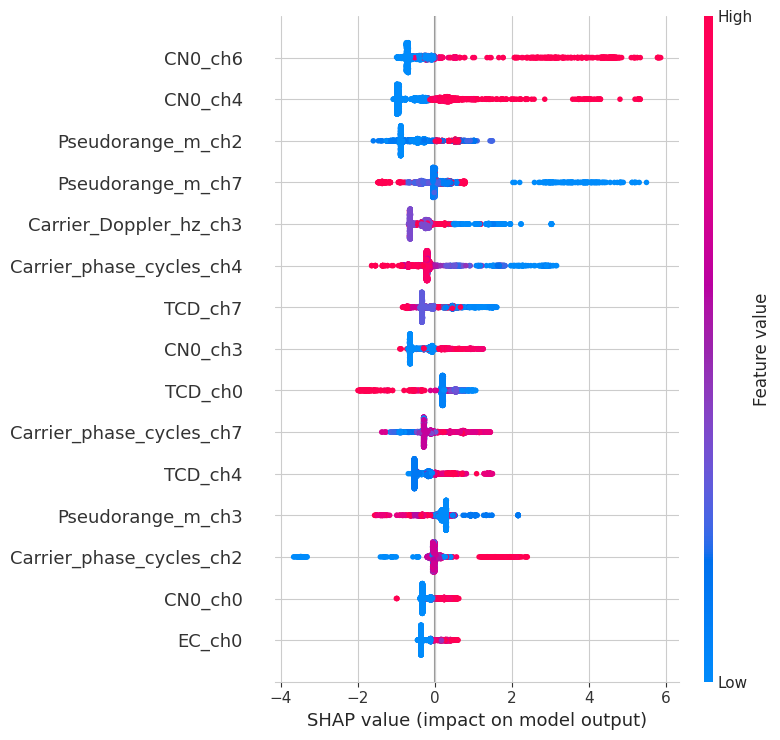

In [12]:
# SHAP beeswarm for top 15 features
fig = plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_COLS, show=False, max_display=15)
plt.tight_layout(); plt.show()

## 7. Save models

In [13]:
joblib.dump({
    'model': model_bin,
    'feature_cols': FEATURE_COLS,
    'task': 'binary',
    'metrics': {
        'f1': float(f1_score(y_te, y_pred_bin)),
        'precision': float(precision_score(y_te, y_pred_bin)),
        'recall': float(recall_score(y_te, y_pred_bin)),
        'auc': float(roc_auc_score(y_te, y_proba_bin)),
    },
    'split': 'random_stratified_80_20_seed42',
}, MODELS / 'xgboost_aissou_binary.joblib')

joblib.dump({
    'model': model_mul,
    'feature_cols': FEATURE_COLS,
    'task': 'multiclass',
    'class_names': ['legit', 'simplistic', 'intermediate', 'sophisticated'],
    'metrics': {
        'accuracy': float((y_te_m == y_pred_m).mean()),
        'f1_macro': float(f1_score(y_te_m, y_pred_m, average='macro')),
        'f1_weighted': float(f1_score(y_te_m, y_pred_m, average='weighted')),
    },
}, MODELS / 'xgboost_aissou_multiclass.joblib')

for p in (MODELS / 'xgboost_aissou_binary.joblib', MODELS / 'xgboost_aissou_multiclass.joblib'):
    print(f'  {p}: {p.stat().st_size/1024:.1f} KB')

  /net/afscra/people/plgmateuszoracz/hackathon/models/xgboost_aissou_binary.joblib: 746.1 KB
  /net/afscra/people/plgmateuszoracz/hackathon/models/xgboost_aissou_multiclass.joblib: 5974.5 KB


## 8. Wnioski

Mamy dwa modele:
- `xgboost_texbat_v1.joblib` — TEXBAT receiver-side observables, F1 ≥ 0.95 z 100% recall w stealth (notebook 03)
- `xgboost_aissou_binary.joblib` + `xgboost_aissou_multiclass.joblib` — UAV on-board, F1 + sophistication classification (ten notebook)

**Demo narrative:** "Receiver-side detection w dwóch warstwach: TEXBAT processed observables dla statycznych/lotniczych, Aissou per-channel statistics dla mobilnych UAV. Ten sam pipeline ML, dwa różne sensory."

Następne notebooki:
- `05_lstm_ae_trajectories.ipynb` (V100) — LSTM autoencoder unsupervised na ADS-B trajektoriach z OpenSky
- `06_opensky_isolationforest.ipynb` — Isolation Forest na trajektoriach dla Live Globe demo